In [1]:
import networkx as nx
from networkx.readwrite import json_graph
from gerrychain import Graph
import matplotlib.pyplot as plt
import requests
import json
import maup
import geopandas as gpd

In [2]:
blocks = gpd.read_file("./ga_2020_gen_2020_blocks/ga_2020_gen_2020_blocks.shp")

In [3]:
block_pop = gpd.read_file("./ga_pl2020_b/ga_pl2020_p2_b.shp")

In [4]:
block_pop_vap = gpd.read_file("./ga_pl2020_b/ga_pl2020_p4_b.shp")

In [5]:
block_pop['Total'] = block_pop['P0020001']
block_pop['Hispanic'] = block_pop['P0020002']
block_pop['NH_White'] = block_pop['P0020005']
# NH_Black captures all census respondents that indicated Black as any of their race selections
block_pop['NH_Black'] = block_pop['P0020006'] + block_pop['P0020013'] + block_pop['P0020018'] + block_pop['P0020019'] + block_pop['P0020020'] + block_pop['P0020021'] + block_pop['P0020029'] + block_pop['P0020030'] + block_pop['P0020031'] + block_pop['P0020032'] + block_pop['P0020039'] + block_pop['P0020040'] + block_pop['P0020041'] + block_pop['P0020042'] + block_pop['P0020043'] + block_pop['P0020044'] + block_pop['P0020050'] + block_pop['P0020051'] + block_pop['P0020052'] + block_pop['P0020053'] + block_pop['P0020054'] + block_pop['P0020055'] + block_pop['P0020060'] + block_pop['P0020061'] + block_pop['P0020062'] + block_pop['P0020063'] + block_pop['P0020066'] + block_pop['P0020067'] + block_pop['P0020068'] + block_pop['P0020069'] + block_pop['P0020071'] + block_pop['P0020073']
block_pop['NH_Other'] = block_pop['Total'] - block_pop['Hispanic'] - block_pop['NH_White'] - block_pop['NH_Black']

block_pop_vap['Total_VAP'] = block_pop_vap['P0040001']
block_pop_vap['Hispanic_VAP'] = block_pop_vap['P0040002']
block_pop_vap['NH_White_VAP'] = block_pop_vap['P0040005']
# NH_Black captures all census respondents that indicated Black as any of their race selections
block_pop_vap['NH_Black_VAP'] = block_pop_vap['P0040006'] + block_pop_vap['P0040013'] + block_pop_vap['P0040018'] + block_pop_vap['P0040019'] + block_pop_vap['P0040020'] + block_pop_vap['P0040021'] + block_pop_vap['P0040029'] + block_pop_vap['P0040030'] + block_pop_vap['P0040031'] + block_pop_vap['P0040032'] + block_pop_vap['P0040039'] + block_pop_vap['P0040040'] + block_pop_vap['P0040041'] + block_pop_vap['P0040042'] + block_pop_vap['P0040043'] + block_pop_vap['P0040044'] + block_pop_vap['P0040050'] + block_pop_vap['P0040051'] + block_pop_vap['P0040052'] + block_pop_vap['P0040053'] + block_pop_vap['P0040054'] + block_pop_vap['P0040055'] + block_pop_vap['P0040060'] + block_pop_vap['P0040061'] + block_pop_vap['P0040062'] + block_pop_vap['P0040063'] + block_pop_vap['P0040066'] + block_pop_vap['P0040067'] + block_pop_vap['P0040068'] + block_pop_vap['P0040069'] + block_pop_vap['P0040071'] + block_pop_vap['P0040073']
block_pop_vap['NH_Other_VAP'] = block_pop_vap['Total_VAP'] - block_pop_vap['Hispanic_VAP'] - block_pop_vap['NH_White_VAP'] - block_pop_vap['NH_Black_VAP']

In [6]:
blocks_w_pop = blocks.merge(block_pop[['GEOID20','Total','Hispanic','NH_White','NH_Black','NH_Other']].set_index('GEOID20'),on="GEOID20")
blocks_w_pop = blocks_w_pop.merge(block_pop_vap[['GEOID20','Total_VAP','Hispanic_VAP','NH_White_VAP','NH_Black_VAP','NH_Other_VAP']].set_index('GEOID20'),on="GEOID20")

In [7]:
blocks_w_pop['population'] = blocks_w_pop['Total']
blocks_w_pop['population_vap'] = blocks_w_pop['Total_VAP']

In [8]:
CON = gpd.read_file("./ga_cong_adopted_2023/Congress-2023 shape.shp")
SLDU = gpd.read_file("./ga_sldu_adopted_2023/Senate-2023 shape file.shp")
SLDL = gpd.read_file("./ga_sldl_adopted_2023/House-2023 shape.shp")

In [9]:
CON = CON.to_crs(blocks_w_pop.crs)
SLDU = SLDU.to_crs(blocks_w_pop.crs)
SLDL = SLDL.to_crs(blocks_w_pop.crs)


bk_to_CON = maup.assign(blocks_w_pop,CON)
bk_to_SLDU = maup.assign(blocks_w_pop,SLDU.to_crs(blocks_w_pop.crs))
bk_to_SLDL = maup.assign(blocks_w_pop,SLDL.to_crs(blocks_w_pop.crs))

C:\Users\angel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\maup\intersections.py:47: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  df = df[df.area > area_cutoff].reset_index(drop=True)
C:\Users\angel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\maup\intersections.py:48: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  geometries = geometries[geometries.area > area_cutoff]
C:\Users\angel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\maup\assign.py:38: UserWarning: Geometry is in a geograp

In [10]:
blocks_w_pop["CON"] = bk_to_CON
blocks_w_pop["SLDU"] = bk_to_SLDU
blocks_w_pop["SLDL"] = bk_to_SLDL

(-85.84627525, -80.54184975, 30.123479699999997, 35.2335803)

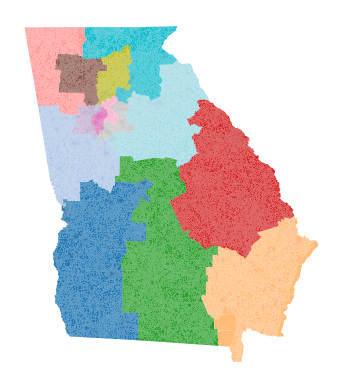

In [11]:
blocks_w_pop.plot(column="CON",cmap='tab20')
plt.axis('off')

In [12]:
precincts = blocks_w_pop[["PRECINCTID","geometry"]].dissolve(by="PRECINCTID")

In [13]:
list(blocks.columns)

['GEOID20',
 'STATEFP',
 'COUNTYFP',
 'PRECINCTID',
 'VAP_MOD',
 'G20PRERTRU',
 'G20PREDBID',
 'G20PRELJOR',
 'G20USSRPER',
 'G20USSDOSS',
 'G20USSLHAZ',
 'G20PSCRSHA',
 'G20PSCDBRY',
 'G20PSCLMEL',
 'G20PSCRMCD',
 'G20PSCDBLA',
 'G20PSCLWIL',
 'geometry']

In [14]:
precincts_w_pop = precincts.merge(blocks_w_pop.groupby("PRECINCTID")[['population','population_vap','G20PRERTRU','G20PREDBID','G20USSRPER','G20USSDOSS','Total','Hispanic','NH_White','NH_Black','NH_Other','Total_VAP','Hispanic_VAP','NH_White_VAP','NH_Black_VAP','NH_Other_VAP']].sum(),on="PRECINCTID")

In [15]:
precincts_w_pop=precincts_w_pop.merge(blocks_w_pop.groupby("PRECINCTID")["COUNTYFP"].max(),on="PRECINCTID")

C:\Users\angel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\maup\intersections.py:47: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  df = df[df.area > area_cutoff].reset_index(drop=True)
C:\Users\angel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\maup\intersections.py:48: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  geometries = geometries[geometries.area > area_cutoff]
C:\Users\angel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\maup\assign.py:38: UserWarning: Geometry is in a geograp

(-85.84627525, -80.54184975, 30.123479699999997, 35.2335803)

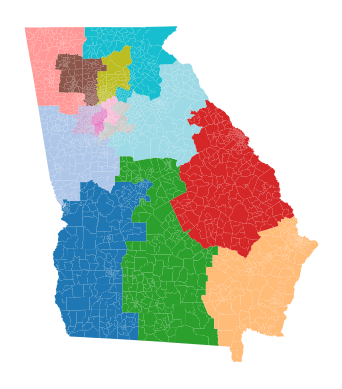

In [16]:
SLDL.set_index('DISTRICT',inplace=True)

p_to_CON = maup.assign(precincts_w_pop,CON)
p_to_SLDU = maup.assign(precincts_w_pop,SLDU.to_crs(precincts_w_pop.crs))
p_to_SLDL = maup.assign(precincts_w_pop,SLDL.to_crs(precincts_w_pop.crs))



precincts_w_pop["CON"] = p_to_CON
precincts_w_pop["SLDU"] = p_to_SLDU
precincts_w_pop["SLDL"] = p_to_SLDL

precincts_w_pop.plot(column="CON",cmap='tab20')
plt.axis('off')

In [17]:
precincts_w_pop['C_X'] = precincts_w_pop.centroid.x
precincts_w_pop['C_Y'] = precincts_w_pop.centroid.y
blocks_w_pop['C_X'] = blocks_w_pop.centroid.x
blocks_w_pop['C_Y'] = blocks_w_pop.centroid.y

C:\Users\angel\AppData\Local\Temp\ipykernel_5032\603903982.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  precincts_w_pop['C_X'] = precincts_w_pop.centroid.x
C:\Users\angel\AppData\Local\Temp\ipykernel_5032\603903982.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  precincts_w_pop['C_Y'] = precincts_w_pop.centroid.y
C:\Users\angel\AppData\Local\Temp\ipykernel_5032\603903982.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  blocks_w_pop['C_X'] = blocks_w_pop.centroid.x
C:\Users\angel\AppData\Local\Temp\ipykernel_5032\603903982.py:4: UserWarning: Geometry is in a

In [ ]:
precinct_graph = Graph.from_geodataframe(precincts_w_pop)


precincts_w_pop.to_file("./output/GA_Processed_Precincts.shp")

precinct_graph.to_json("./output/GA_Processed_Precincts.json")

C:\Users\angel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\gerrychain\graph\graph.py:266: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  areas = df.geometry.area.to_dict()
C:\Users\angel\AppData\Local\Temp\ipykernel_5032\2417705801.py:4: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  precincts_w_pop.to_file("./GA_Processed_Precincts.shp")
